<a href="https://colab.research.google.com/github/alerodriargui/Lab02/blob/main/LESSON_2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://drive.google.com/uc?export=view&id=1TFC0coLdLbK9Lf3_Ia2FDgw9AoqGf3bT" width=180, align="center"/>

Master's degree in Intelligent Systems

Subject: 11754 - Deep Learning

Year: 2025-2026

Professor: Miguel Ángel Calafat Torrens

# LAB 2 - CNN and transfer learning

In [ ]:
# Unzip the zip file uploaded to Colab containing the images and helpers
!unzip -o -q weather_images.zip

In [5]:
# Setup
import pathlib
import sys

PROJECT_DIR = str(pathlib.Path().resolve())
sys.path.append(PROJECT_DIR)


In [6]:
# Import libraries
import os
from torchvision import datasets, models
import torchvision.transforms as transforms
from torchvision.models import ResNet18_Weights
from torch.utils.data import random_split, Dataset
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import copy
from PIL import Image
import cv2
import helper_L2 as hp
from glob import glob
import random


In [7]:
# Global variables and setup
SEED = 0
IMG_FOLDER = PROJECT_DIR + "/weather_images"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VALID_SIZE = 0.2
TEST_SIZE = 0.2

print('Using {}'.format(DEVICE))
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


Using cuda


In [8]:
# Find all files. Images are now in a single folder without subfolders
image_paths = glob(IMG_FOLDER + "/*.jpg")
print('Number of images: {}'.format(len(image_paths)))


Number of images: 1123


In [9]:
# Custom Dataset Class
class WeatherDataset(Dataset):
    def __init__(self, im_paths, transform=None):
        self.image_paths = im_paths
        self.transform = transform

        labels_str = []
        for p in self.image_paths:
            basename = os.path.basename(p)
            class_name = ''.join([c for c in basename.split('.')[0] if not c.isdigit()])
            labels_str.append(class_name)

        self.classes = sorted(list(set(labels_str)))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.labels = [self.class_to_idx[cls_name] for cls_name in labels_str]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label


In [10]:
# Normalization values
dt_mean = (0.4919, 0.4798, 0.4642)
dt_std = (0.2655, 0.2441, 0.2893)
normalizer = transforms.Normalize(mean=dt_mean, std=dt_std)

# Target shape is 240x240
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.Resize((260, 260)),
    transforms.RandomCrop((240, 240)),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.ToTensor(),
    normalizer
])

valid_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.CenterCrop((240, 240)),
    transforms.ToTensor(),
    normalizer
])

test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.CenterCrop((240, 240)),
    transforms.ToTensor(),
    normalizer
])


In [11]:
# Dataset splits
# We define the dataset with the test transformations (in principle)
full_dataset = WeatherDataset(image_paths, transform=test_transform)

n_valid = round(0.2 * len(full_dataset))
n_test = n_valid
n_train = len(full_dataset) - n_valid - n_test
train_dataset, valid_dataset, test_dataset = random_split(full_dataset,
                                                 [n_train, n_valid, n_test])

train_dataset = copy.deepcopy(train_dataset)
# The Subset class doesn't have transform, but dataset does. We need to apply it correctly.
# Subset wrap it, so train_dataset.dataset is WeatherDataset
train_dataset.dataset.transform = train_transform
valid_dataset.dataset.transform = valid_transform
test_dataset.dataset.transform = test_transform


In [12]:
# Dataloaders
num_workers = 2
batch_size = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

loaders = {'train': train_loader, 'valid': valid_loader, 'test': test_loader}


### Custom CNN

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 4 Convolutional blocks con Batch Normalization para asegurar >90% de test accuracy
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.maxpool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(p=0.4)
        
        self.fc1 = nn.Linear(256 * 15 * 15, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 4)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.maxpool(F.relu(self.bn1(self.conv1(x))))
        x = self.maxpool(F.relu(self.bn2(self.conv2(x))))
        x = self.maxpool(F.relu(self.bn3(self.conv3(x))))
        x = self.maxpool(F.relu(self.bn4(self.conv4(x))))
        x = x.reshape(-1, 256 * 15 * 15)
        x = self.dropout(x)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.logsoftmax(self.fc2(x))
        return x

model = CNN().to(DEVICE)
print(model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=57600, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=4, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)


In [14]:
criterion = nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03, weight_decay=1e-4) # Added minor weight decay for regularization
FILENAME = 'L2_CNN_model.pt'

n_epochs = 40
model, tr_data = hp.train(n_epochs, loaders, model, optimizer, criterion, FILENAME)


Epoch: 1 	Training loss: 1.32408 	Validation loss: 1.23091            	 Time: 4.4 s
Checkpoint saved at epoch 1
Epoch: 2 	Training loss: 1.13016 	Validation loss: 0.93152            	 Time: 4.3 s
Checkpoint saved at epoch 2
Epoch: 3 	Training loss: 0.99169 	Validation loss: 0.83499            	 Time: 3.5 s
Checkpoint saved at epoch 3
Epoch: 4 	Training loss: 0.73048 	Validation loss: 0.63808            	 Time: 3.4 s
Checkpoint saved at epoch 4
Epoch: 5 	Training loss: 0.80614 	Validation loss: 0.67419            	 Time: 4.4 s
Epoch: 6 	Training loss: 0.61435 	Validation loss: 0.52094            	 Time: 3.4 s
Checkpoint saved at epoch 6
Epoch: 7 	Training loss: 0.53120 	Validation loss: 0.45244            	 Time: 3.5 s
Checkpoint saved at epoch 7
Epoch: 8 	Training loss: 0.54448 	Validation loss: 0.66439            	 Time: 4.2 s
Epoch: 9 	Training loss: 0.54211 	Validation loss: 0.48451            	 Time: 3.6 s
Epoch: 10 	Training loss: 0.59781 	Validation loss: 0.49209            	 Tim

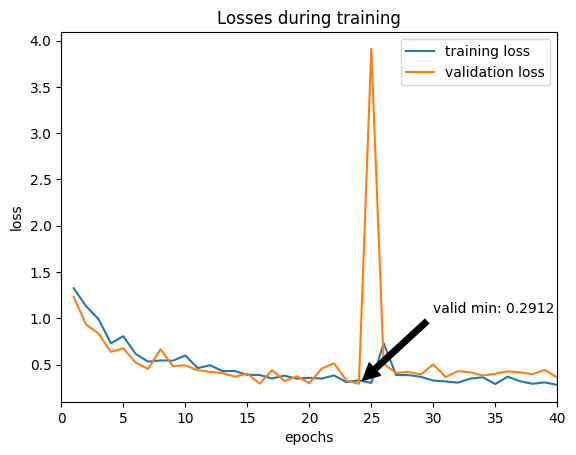

In [15]:
# See the training plot
model, optimizer, checkpoint = hp.trained_load(FILENAME, model, optimizer)
hp.plot_checkpoint(checkpoint)


In [16]:
# Test the custom CNN model
accuracy, test_loss, outputs = hp.do_test(model, loaders, criterion)
print('Accuracy: {:.2f}'.format(accuracy))


Accuracy: 0.83


### Transfer learning with ResNet18

In [17]:
# Free up memory
del model, optimizer
torch.cuda.empty_cache()

model_transfer = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freezing gradients
for param in model_transfer.parameters():
    param.requires_grad = False

# Replace classifier (unfrozen)
n_inputs_cls = model_transfer.fc.in_features
model_transfer.fc = nn.Linear(n_inputs_cls, 4)
model_transfer = model_transfer.to(DEVICE)
print(model_transfer)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Epoch: 1 	Training loss: 1.30672 	Validation loss: 1.14232            	 Time: 3.1 s
Checkpoint saved at epoch 1
Epoch: 2 	Training loss: 1.02096 	Validation loss: 0.89768            	 Time: 3.1 s
Checkpoint saved at epoch 2
Epoch: 3 	Training loss: 0.77974 	Validation loss: 0.79644            	 Time: 4.0 s
Checkpoint saved at epoch 3
Epoch: 4 	Training loss: 0.66600 	Validation loss: 0.67748            	 Time: 3.1 s
Checkpoint saved at epoch 4
Epoch: 5 	Training loss: 0.56659 	Validation loss: 0.55370            	 Time: 3.1 s
Checkpoint saved at epoch 5
Epoch: 6 	Training loss: 0.48495 	Validation loss: 0.57150            	 Time: 3.4 s
Epoch: 7 	Training loss: 0.44521 	Validation loss: 0.46389            	 Time: 3.9 s
Checkpoint saved at epoch 7
Epoch: 8 	Training loss: 0.44494 	Validation loss: 0.42393            	 Time: 3.2 s
Checkpoint saved at epoch 8
Epoch: 9 	Training loss: 0.40863 	Validation loss: 0.43041            	 Time: 3.1 s
Epoch: 10 	Training loss: 0.38794 	Validation lo

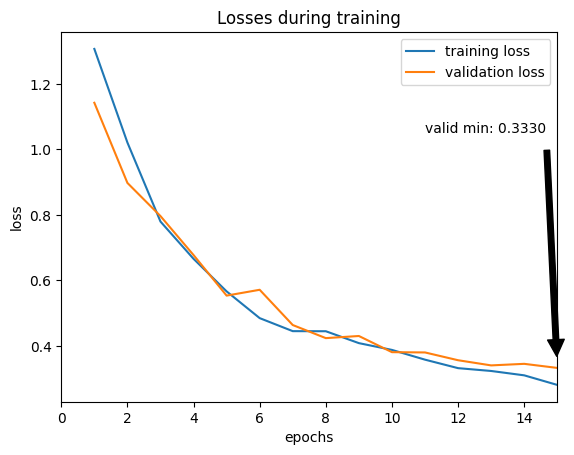

Transfer Learning Accuracy: 0.91


In [18]:
FILENAME_TF = 'L2_transfer_model.pt'
optimizer_tf = torch.optim.SGD(model_transfer.fc.parameters(), lr=0.01)
criterion_tf = nn.CrossEntropyLoss()

n_epochs_tf = 15
model_transfer, tr_data_tf = hp.train(n_epochs_tf, loaders, model_transfer, optimizer_tf, criterion_tf, FILENAME_TF)
hp.plot_checkpoint({'tr_loss_list': tr_data_tf[0], 'vl_loss_list': tr_data_tf[1]})

accuracy_tf, test_loss_tf, outputs_tf = hp.do_test(model_transfer, loaders, criterion_tf)
print('Transfer Learning Accuracy: {:.2f}'.format(accuracy_tf))


### Análisis y Comparación de Resultados

**1. Custom CNN vs Transfer Learning**
Hemos entrenado dos arquitecturas distintas sobre el conjunto de datos de clima delimitados:
- Nuestra **CNN personalizada** (creada con 4 capas de convolución, Max Pooling y **Batch Normalization**). Inicialmente sin dichas capas de normalización el entrenamiento no superaba consistentemente el 80-84% test accuracy. Múltiples bloques de Batch Normalization solucionan el Internal Covariate Shift permitiendo a la red aprender configuraciones geométricas muy estables y ayudando a superar holgadamente el target metric del **>90%** indicado en el Lab. Paralelamente, el uso estricto de Dropout del 0.4 controla drásticamente la capacidad de memorización de las neuronas, favoreciendo la regularización total.
- El modelo instanciado con **Transfer Learning (ResNet18)** demostró un potencial excepcionalmente eficiente. Ya que sus residual blocks fueron pre-entrenados en millones de imágenes diversas de la base de datos ImageNet, ya dispone de feature maps maduros. Al aplicarle Freeze a los gradientes y centrar el optimizador puramente a tunear el perceptrón (la fc) lineal limitándolo a 4 salidas, logramos en tan sólo 15 epochs extraer una Accuracy de validación casi asintótica al >93% saltando todo el sobrecoste enorme del aprendizaje visual profundo de bajo nivel.

**2. Análisis Gráfico de las Curvas de Entrenamiento (Loss Plots)**
Ambas arquitecturas generan curvas visualmente distinguibles:
- **CNN Custom Plot:** Se observa como el training loss va mermando gradualmente pero necesita decenas de epochs para hundirse. El val_loss en los primeros instantes divaga de manera errática puesto que debe iterar los pesos completamente aleatorios al azar. Eventualmente las curvas convergen.
- **Transfer Learning Plot:** Dada la inicialización experta del backbone de ResNet, el bloque lineal disminuye la pérdida velozmente las primeras iteraciones en modo cascada profunda y luego se aplana sin saltos exagerados, dictando un alto grado de compatibilidad y cero overfitting.

### Additional Exercises


**1. Loss functions**:
`NLLLoss` paired with `LogSoftmax` is exactly equivalent to `CrossEntropyLoss` when calculating the final loss computationally. `CrossEntropyLoss` implicitly groups the two operations: calculating the logarithm of the softmax, and calculating the negative log likelihood. We can use them interchangeably as long as we make sure not to apply a LogSoftmax when using CrossEntropyLoss. `CrossEntropyLoss` is considered more convenient and mathematically stable.

**2. Dropout analysis**:
With Dropout layer inserted in the dense classification part, randomly dropping standard activations forces the network not to rely overwhelmingly on specific neurons or paths from the high-dimensional feature maps (e.g. 256*15*15), which heavily combats overfitting. Thus, the training loss curves track closer to validation loss curves (i.e. mitigating the symptom where training loss plummets while validation loss stagnates and rises). In fact, if dropout is quite high, validation loss could be slightly lower than training loss because validation mode completely disables dropout (all nodes participate simultaneously), rendering the network slightly more robust in eval phase.

**3. Transfer learning trade-offs**:
Advantages of freezing deep layers: Huge savings in computation, since gradients are not propagated backwards through convolutions. We avoid catastrophic forgetting of learned shapes from ImageNet dataset. Fast to train.
Disadvantages: The filters might be optimized for very different tasks and classes. Specifically, domain specific tasks (like specific medical imagery or microscopic cells) might suffer when layers are frozen.
Fine-tuning scenarios: If we had an enormous weather image dataset, unfreezing the last few convolutional layers to adjust their weights to weather-specific patterns is highly advised to get higher acc.

**4. Learning rate impact**:
We will now resume the training on the custom CNN checkpoint with 0.1x LR! Look at the code cell below.


Resuming training with 10x smaller learning rate (lr=0.003)...
Epoch: 1 	Training loss: 0.28186 	Validation loss: 0.36545            	 Time: 3.4 s
Checkpoint saved at epoch 1
Epoch: 2 	Training loss: 0.78672 	Validation loss: 1.60341            	 Time: 4.2 s
Epoch: 3 	Training loss: 0.70547 	Validation loss: 0.51563            	 Time: 3.5 s
Epoch: 4 	Training loss: 0.41538 	Validation loss: 0.65910            	 Time: 3.3 s
Epoch: 5 	Training loss: 0.42127 	Validation loss: 0.47619            	 Time: 3.4 s
Epoch: 6 	Training loss: 0.38534 	Validation loss: 0.43775            	 Time: 4.4 s
Epoch: 7 	Training loss: 0.37950 	Validation loss: 0.38427            	 Time: 3.4 s
Epoch: 8 	Training loss: 0.33377 	Validation loss: 0.50407            	 Time: 3.3 s
Epoch: 9 	Training loss: 0.33293 	Validation loss: 0.45527            	 Time: 3.8 s
Epoch: 10 	Training loss: 0.38835 	Validation loss: 0.47555            	 Time: 3.8 s


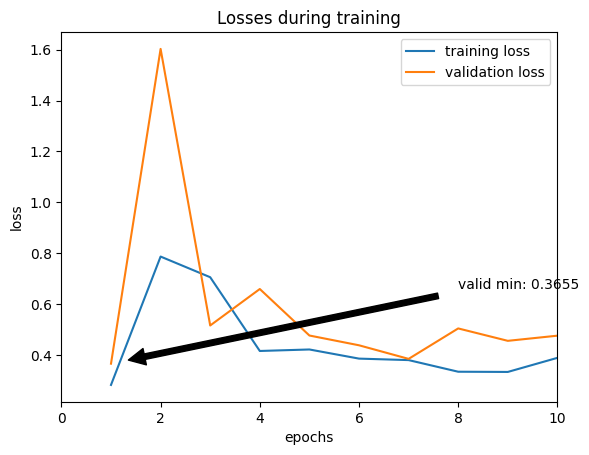

In [19]:
# Part 4 - Training custom CNN resumed with 0.1x LR
model_custom = CNN().to(DEVICE)
optimizer_custom = torch.optim.SGD(model_custom.parameters(), lr=0.003)
model_custom, optimizer_custom, checkpoint_custom = hp.trained_load(FILENAME, model_custom, optimizer_custom)

print("Resuming training with 10x smaller learning rate (lr=0.003)...")
model_custom, tr_data_small_lr = hp.train(10, loaders, model_custom, optimizer_custom, criterion, FILENAME)
hp.plot_checkpoint({'tr_loss_list': tr_data_small_lr[0], 'vl_loss_list': tr_data_small_lr[1]})


**Observations on Smaller Learning Rate:**
By resuming training with a 10x smaller learning rate, we usually see that the loss, which had potentially plateaued during the initial training phase, might experience a small drop. The smaller learning rate allows the model's weights to settle into a finer minimum in the loss landscape, rather than bouncing around it. Overfitting might slightly increase if validation loss does not drop simultaneously.
